# PHASE 1 - EEG PREPROCESSING

### STEP 1 - LOAD DATA 

In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# Imports
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path       
import numpy as np               
import pandas as pd             
import mne                       
from tqdm import tqdm 
from datetime import datetime
import re

# ══════════════════════════════════════════════════════════════════════════════
# Configuration - all data files are stored in these base directories + output folder
# ══════════════════════════════════════════════════════════════════════════════

BASE_DIRS = [
    Path(r"\\vs03.herseninstituut.knaw.nl\VS03-SandC-2\raw\bnbd\Data\eeg\NSR"),
    Path(r"\\vs03.herseninstituut.knaw.nl\VS03-SandC-2\raw\bnbd\Data\eeg\Prezens"),
    Path(r"\\vs03.herseninstituut.knaw.nl\VS03-SandC-2\raw\bnbd\Data\eeg\SAV"),
]
output_dir = Path(r"C:\Users\zafar\Documents\THESIS_OUTPUTS\1_preprocessing_EEG")
output_dir.mkdir(exist_ok=True)

EEG_CH = ['EEG L psg-lp', 'EEG R psg-lp']          # EEG channels left and right 
EMG_CH = ['EEG L psg-emg', 'EEG R psg-emg']        # EMG channels (muscle activity)
MOV_CH = ['dX', 'dY', 'dZ']                        # movement channels (accelerometer)
ALL_CH = EEG_CH + EMG_CH + MOV_CH                  # all channels together

L_FREQ   = 0.1                                     # Hz deletes slow drifts and DC offset 
H_FREQ   = 35.0                                    # Hz enough for all relevant EEG activity (delta, theta, alpha, beta)
NOTCH_HZ = 50.0 
SFREQ    = 256                                     # Original sampling frequency of the data
MOVEMENT_THRESHOLD_UV = 1000.0                     # Way above normal EEG (~200mV) 
TARGET_SFREQ = 128                                 # Resampling if needed
GROUPS = ["NSR", "Prezens", "SAV"]


In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# Help functions
# ══════════════════════════════════════════════════════════════════════════════

def find_edf_files(base_dirs: list, limit: int = None) -> list:
    """
    Zoekt EDF-bestanden via rglob("*_psg.edf").
    Slaat de lijst op als edf_filelist.csv zodat het bij herstart niet opnieuw hoeft.
    Verwijder edf_filelist.csv handmatig als je een nieuwe scan wilt forceren.
    """
    cache_path = OUTPUT_DIR / "edf_filelist.csv"

    # ── Laad uit cache als die bestaat ───────────────────────────
    if cache_path.exists():
        cached = pd.read_csv(cache_path)["file_path"].tolist()
        all_files = [Path(p) for p in cached]
        print(f"  [CACHE] {len(all_files)} bestanden geladen uit {cache_path.name}")
        print(f"          (verwijder dit bestand om opnieuw te scannen)")

    # ── Anders: scan de mappen en sla op ─────────────────────────
    else:
        print("  [SCAN] Geen cache gevonden, mappen worden gescand...")
        all_files = []

        for base in base_dirs:
            if not base.exists():
                print(f"  [WARN] Niet bereikbaar: {base}")
                continue

            found = sorted(f for f in base.rglob("*_psg.edf") if "_T0_" in f.name)          # only T0 files       
            print(f"  {len(found):>5} gevonden (T0)  ← {base.name}")
            all_files.extend(found)

        # Opslaan als cache
        pd.DataFrame({"file_path": [str(f) for f in all_files]}).to_csv(cache_path, index=False)
        print(f"\n  [CACHE] Lijst opgeslagen: {cache_path.name}")

    if limit:
        print(f"  [INFO] Limiet: eerste {limit} bestanden")
        all_files = all_files[:limit]

    print(f"\n  → Totaal te verwerken: {len(all_files)} bestanden")
    return all_files


def extract_ids(edf_path: Path) -> dict:
    """
    Haalt subject_id en night_id uit de bestandsnaam.
    Exact zoals jouw originele code:

    Bestandsnaam: bnbd_nsr_03554_T0_N1_psg.edf
    stem:         bnbd_nsr_03554_T0_N1_psg
    na _psg:      bnbd_nsr_03554_T0_N1
    parts:        ['bnbd', 'nsr', '03554', 'T0', 'N1']

    subject_id →  bnbd_nsr_03554
    night_id   →  T0_N1
    group      →  nsr / sav / prezens (uit parts[1])
    """
    stem  = edf_path.stem                        # zonder .edf
    parts = stem.replace("_psg", "").split("_")  # verwijder _psg suffix

    subject_id = f"bnbd_{parts[1]}_{parts[2]}"  # bnbd_nsr_03554
    night_id   = f"{parts[3]}_{parts[4]}"        # T0_N1
    group      = parts[1].upper()                # NSR / SAV / PREZENS

    return {
        "subject_id":    subject_id,
        "night_id":      night_id,
        "group":         group,
        "participant_id": subject_id,            # alias voor compatibiliteit
    }

### STEP 2 - PREPROCESS EEG DATA 

In [80]:
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import mne

OUTPUT_DIR = Path(r"C:\Users\zafar\Documents\THESIS_OUTPUTS\1_preprocessing_EEG")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# Preprocessing functions
# ══════════════════════════════════════════════════════════════════════════════

def load_night(edf_file: Path):
    """Laadt één EDF en past DC-removal, notch, bandpass en resampling toe."""
    raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)

    available   = raw.ch_names
    ch_to_pick  = [ch for ch in ALL_CH if ch in available]
    eeg_present = [ch for ch in EEG_CH  if ch in available]
    emg_present = [ch for ch in EMG_CH  if ch in available]
    mov_present = [ch for ch in MOV_CH  if ch in available]
    missing     = [ch for ch in ALL_CH  if ch not in available]

    if missing:
        print(f"    [WARN] Kanalen niet gevonden: {missing}")
    if not eeg_present:
        raise ValueError("Geen EEG-kanalen aanwezig.")

    raw.pick(ch_to_pick)
    raw.load_data(verbose=False)
    raw._data = raw._data.astype(np.float64)

    sfreq_orig = raw.info["sfreq"]

    # 1. Delete DC offset 
    for ch in eeg_present:
        idx = raw.ch_names.index(ch)
        raw._data[idx] -= np.mean(raw._data[idx])

    # 2. Notch 50 Hz
    if sfreq_orig > NOTCH_HZ * 2:
        raw.notch_filter(freqs=NOTCH_HZ, picks=eeg_present, verbose=False)

    # 3. Bandpass EEG: 0.1–35 Hz
    raw.filter(l_freq=L_FREQ, h_freq=H_FREQ,
               picks=eeg_present, method="fir",
               fir_window="hamming", verbose=False)

    # 4. EMG filter
    if emg_present:
        h_emg = min(100.0, sfreq_orig / 2 - 1)
        raw.filter(l_freq=10.0, h_freq=h_emg, picks=emg_present, verbose=False)

    # 5. MOVEMENT: DC removal
    if mov_present:
        raw.apply_function(lambda x: x - np.mean(x), picks=mov_present, verbose=False)

    # 6. Resample naar 128 Hz
    if sfreq_orig != TARGET_SFREQ:
        raw.resample(TARGET_SFREQ, verbose=False)

    return raw


def preprocess_signals(raw) -> dict:
    """Geeft dictionary: kanaalnaam → 1D numpy array."""
    return {ch: raw.get_data(picks=ch)[0] for ch in ALL_CH if ch in raw.ch_names}


def remove_movement_artifacts(signals: dict, sfreq: int = TARGET_SFREQ) -> tuple:
    n_samples     = len(next(iter(signals.values())))
    combined_mask = np.zeros(n_samples, dtype=bool)
    buffer        = int(0.5 * sfreq)
    stats         = {}

    for ch in EEG_CH:
        if ch not in signals:
            continue

        # data is al in µV, dus direct vergelijken met drempel in µV
        mask         = np.abs(signals[ch]) > MOVEMENT_THRESHOLD_UV
        mask_dilated = np.zeros(n_samples, dtype=bool)
        for idx in np.where(mask)[0]:
            mask_dilated[max(0, idx - buffer):min(n_samples, idx + buffer)] = True
        stats[ch]     = round(mask_dilated.mean() * 100, 2)
        combined_mask |= mask_dilated

    return combined_mask, stats


# ══════════════════════════════════════════════════════════════════════════════
# Processing of 1 night 
# ══════════════════════════════════════════════════════════════════════════════
def already_preprocessed(edf_path: Path) -> bool:
    """Checkt of het .fif outputbestand al bestaat."""
    ids      = extract_ids(edf_path)
    out_path = OUTPUT_DIR / ids["group"] / ids["subject_id"] / (edf_path.stem + "_prep_raw.fif")
    return out_path.exists()

def process_one_night(edf_path: Path) -> dict:
    """Volledige pipeline voor één EDF-bestand."""
    ids      = extract_ids(edf_path)
    save_dir = OUTPUT_DIR / ids["group"] / ids["subject_id"]
    out_path = save_dir / (edf_path.stem + "_prep_raw.fif")

    log = {
        "file_path":          str(edf_path),
        "group":              ids["group"],
        "subject_id":         ids["subject_id"],
        "night_id":           ids["night_id"],
        "status":             "failed",
        "error":              "",
        "sfreq_original":     "",
        "duration_hours":     "",
        "movement_pct_L":     "",
        "movement_pct_R":     "",
        "preprocessed_path":  str(out_path),
        "timestamp":          datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    # Skip als .fif al bestaat
    if out_path.exists():
        try:
            raw = mne.io.read_raw_fif(out_path, preload=False, verbose=False)
            log.update({
                "status":         "skipped",
                "sfreq_original": raw.info["sfreq"],
                "duration_hours": round(raw.times[-1] / 3600, 3),
            })
        except Exception:
            log["status"] = "skipped"
        return log

    try:
        raw         = load_night(edf_path)
        signals     = preprocess_signals(raw)
        mask, stats = remove_movement_artifacts(signals)

        save_dir.mkdir(parents=True, exist_ok=True)
        raw.save(out_path, overwrite=True, verbose=False)

        log.update({
            "status":           "ok",
            "sfreq_original":   raw.info["sfreq"],
            "duration_hours":   round(raw.times[-1] / 3600, 3),
            "movement_pct_L":   stats.get(EEG_CH[0], ""),
            "movement_pct_R":   stats.get(EEG_CH[1], ""),
        })

    except Exception as e:
        log["error"] = str(e)

    return log

# ══════════════════════════════════════════════════════════════════════════════
# MAIN - batch processing 
# ══════════════════════════════════════════════════════════════════════════════

def run_batch(limit: int = None):
    print("=" * 65)
    print("  EEG BATCH PREPROCESSING — Stap 3 t/m 7")
    print(f"  Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 65)

    print("\n[1/2] EDF-bestanden zoeken...")
    all_files = find_edf_files(BASE_DIRS, limit=limit)

    # ── Filter al verwerkte bestanden eruit ──────────────────────
    todo  = [f for f in all_files if not already_preprocessed(f)]
    done  = len(all_files) - len(todo)
    print(f"\n  Al verwerkt (overgeslagen) : {done}")
    print(f"  Nog te verwerken           : {len(todo)}")

    if not todo:
        print("\n[KLAAR] Alle bestanden zijn al verwerkt.")
        return

    print("\n[2/2] Preprocessing starten...\n")

    log_path = OUTPUT_DIR / "preprocessing_log.csv"
    log_rows = []
    n_ok, n_fail = 0, 0

    for i, edf_path in enumerate(todo, start=1):
        pct = i / len(todo) * 100
        print(f"  [{i:>4}/{len(todo)}  {pct:>5.1f}%]  {edf_path.name}", end="  →  ", flush=True)

        log = process_one_night(edf_path)
        log_rows.append(log)

        if log["status"] == "ok":
            n_ok += 1
            print(f"OK  ({log['duration_hours']} h  |  "
                  f"beweging L={log['movement_pct_L']}%  R={log['movement_pct_R']}%)")
        else:
            n_fail += 1
            print(f"FAIL  {log['error'][:80]}")

        if i % 25 == 0 or i == len(todo):
            pd.DataFrame(log_rows).to_csv(log_path, index=False)

    print("\n" + "=" * 65)
    print(f"  Succesvol      : {n_ok}")
    print(f"  Mislukt        : {n_fail}")
    print(f"  Log            : {log_path}")
    print(f"  Einde          : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 65)

# ─── Start ────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # !! EERST TESTEN op X bestanden !!
    # Als alles OK is: verander naar run_batch(limit=None)
    run_batch(limit=31)

  EEG BATCH PREPROCESSING — Stap 3 t/m 7
  Start: 2026-05-13 15:34:22

[1/2] EDF-bestanden zoeken...
  [CACHE] 910 bestanden geladen uit edf_filelist.csv
          (verwijder dit bestand om opnieuw te scannen)
  [INFO] Limiet: eerste 31 bestanden

  → Totaal te verwerken: 31 bestanden

  Al verwerkt (overgeslagen) : 30
  Nog te verwerken           : 1

[2/2] Preprocessing starten...

  [   1/1  100.0%]  bnbd_nsr_08850_T0_N3_psg.edf  →  

OK  (8.987 h  |  beweging L=0.15%  R=0.2%)

  Succesvol      : 1
  Mislukt        : 0
  Log            : C:\Users\zafar\Documents\THESIS_OUTPUTS\1_preprocessing_EEG\preprocessing_log.csv
  Einde          : 2026-05-13 15:34:32


### STEP 3 - VERIFY PREPROCESSING 


── Verificatie: bnbd_nsr_01272_T0_N3_psg.edf ──

  [1] DC offset:
      Voor  : -2.82 µV
      Na    : -0.01 µV  ✓ OK

  [2] Sampling frequency:
      Voor  : 256.0 Hz
      Na    : 128.0 Hz  ✓ OK

  [3] Notch filter (50 Hz power):
      Voor  : -35.5 dB
      Na    : -101.5 dB  ✓ OK (>10 dB reductie)

  [4] Bandpass (0.1–35 Hz):
      Power in band (1–30 Hz) : 74.4570
      Power buiten (>36 Hz)   : 0.0033  ✓ OK


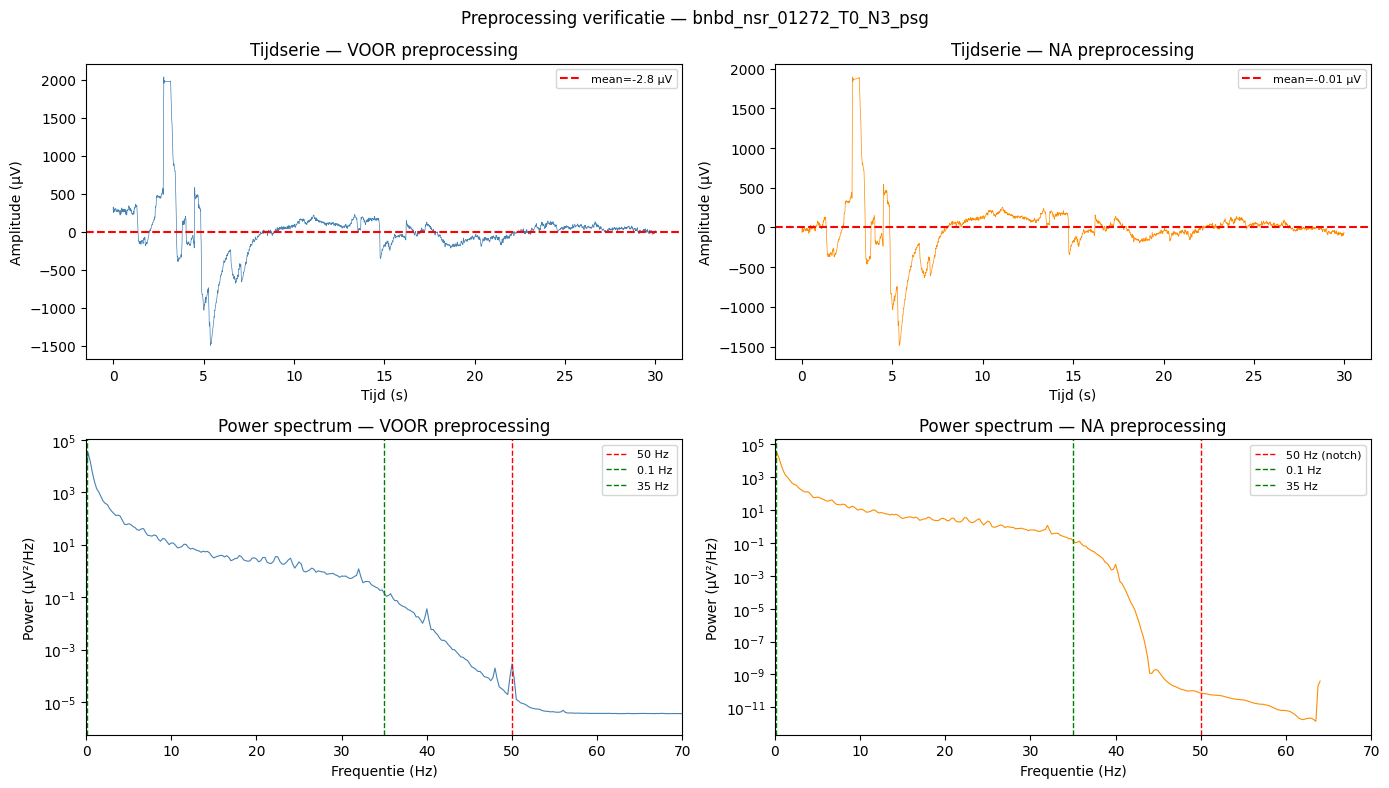


  Plot opgeslagen: verify_bnbd_nsr_01272_T0_N3_psg.png

  ✓ Preprocessing correct
──────────────────────────────────────────────────


In [28]:
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

def verify_preprocessing(edf_path: Path):
    """
    Vergelijkt ruwe vs preprocessed data op 4 dingen:
    1. DC offset (mean ≈ 0 na removal)
    2. Notch filter (50 Hz piek weg)
    3. Bandpass (niets buiten 0.1–35 Hz)
    4. Resampling (sfreq = 128 Hz)
    """

    print(f"\n── Verificatie: {edf_path.name} ──")

    # ── Laad RAW (ongefilterd) ────────────────────────────────────
    raw_orig = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw_orig.pick([ch for ch in EEG_CH if ch in raw_orig.ch_names])
    ch = raw_orig.ch_names[0]   # gebruik linker EEG kanaal
    data_raw = raw_orig.get_data(picks=ch)[0]
    sfreq_raw = raw_orig.info["sfreq"]

    # ── Laad PREPROCESSED (.fif) ──────────────────────────────────
    ids     = extract_ids(edf_path)
    fif_path = OUTPUT_DIR / ids["group"] / ids["subject_id"] / (edf_path.stem + "_prep_raw.fif")

    if not fif_path.exists():
        print(f"  [WARN] Geen .fif gevonden: {fif_path}")
        print(f"         Voer eerst run_batch() uit.")
        return

    raw_prep = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
    ch_prep  = raw_prep.ch_names[0]
    data_prep = raw_prep.get_data(picks=ch_prep)[0]
    sfreq_prep = raw_prep.info["sfreq"]

    # ══════════════════════════════════════════════════════════════
    # CHECK 1 — DC offset
    # ══════════════════════════════════════════════════════════════
    mean_raw  = data_raw.mean()
    mean_prep = data_prep.mean()
    dc_ok     = abs(mean_prep) < 1.0   # moet < 1 µV zijn

    print(f"\n  [1] DC offset:")
    print(f"      Voor  : {mean_raw:+.2f} µV")
    print(f"      Na    : {mean_prep:+.2f} µV  {'✓ OK' if dc_ok else '✗ PROBLEEM'}")

    # ══════════════════════════════════════════════════════════════
    # CHECK 2 — Resampling
    # ══════════════════════════════════════════════════════════════
    resamp_ok = sfreq_prep == TARGET_SFREQ
    print(f"\n  [2] Sampling frequency:")
    print(f"      Voor  : {sfreq_raw} Hz")
    print(f"      Na    : {sfreq_prep} Hz  {'✓ OK' if resamp_ok else '✗ PROBLEEM'}")

    # ══════════════════════════════════════════════════════════════
    # CHECK 3 + 4 — Power spectrum (notch + bandpass visueel)
    # ══════════════════════════════════════════════════════════════
    # Welch PSD voor beide signalen
    # nperseg=4*sfreq → frequentieresolutie van 0.25 Hz
    freqs_raw,  psd_raw  = scipy_signal.welch(data_raw,  fs=sfreq_raw,  nperseg=int(4*sfreq_raw))
    freqs_prep, psd_prep = scipy_signal.welch(data_prep, fs=sfreq_prep, nperseg=int(4*sfreq_prep))

    # Check 50 Hz power (notch)
    idx_50_raw  = np.argmin(np.abs(freqs_raw  - 50))
    idx_50_prep = np.argmin(np.abs(freqs_prep - 50))
    power_50_raw  = 10 * np.log10(psd_raw[idx_50_raw]  + 1e-30)
    power_50_prep = 10 * np.log10(psd_prep[idx_50_prep] + 1e-30)
    notch_ok = power_50_prep < power_50_raw - 10   # minstens 10 dB minder

    print(f"\n  [3] Notch filter (50 Hz power):")
    print(f"      Voor  : {power_50_raw:.1f} dB")
    print(f"      Na    : {power_50_prep:.1f} dB  {'✓ OK (>10 dB reductie)' if notch_ok else '✗ CHECK DIT'}")

    # Check bandpass: bijna geen power buiten 0.1–35 Hz
    mask_out  = freqs_prep > 36   # boven 35 Hz
    power_out = psd_prep[mask_out].mean() if mask_out.any() else 0
    mask_in   = (freqs_prep >= 1) & (freqs_prep <= 30)
    power_in  = psd_prep[mask_in].mean()
    bandpass_ok = power_out < power_in * 0.01   # buiten band < 1% van binnen

    print(f"\n  [4] Bandpass (0.1–35 Hz):")
    print(f"      Power in band (1–30 Hz) : {power_in:.4f}")
    print(f"      Power buiten (>36 Hz)   : {power_out:.4f}  {'✓ OK' if bandpass_ok else '✗ CHECK DIT'}")

    # ══════════════════════════════════════════════════════════════
    # PLOT — Tijdserie + Power spectrum
    # ══════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Preprocessing verificatie — {edf_path.stem}", fontsize=12)

    t_show = 30   # toon eerste 30 seconden

    # ── Tijdserie voor ───────────────────────────────────────────
    samp_raw  = int(t_show * sfreq_raw)
    t_raw     = np.arange(samp_raw) / sfreq_raw
    axes[0,0].plot(t_raw, data_raw[:samp_raw], lw=0.5, color="steelblue")
    axes[0,0].axhline(mean_raw, color="red", lw=1.5, linestyle="--", label=f"mean={mean_raw:+.1f} µV")
    axes[0,0].set_title("Tijdserie — VOOR preprocessing")
    axes[0,0].set_xlabel("Tijd (s)")
    axes[0,0].set_ylabel("Amplitude (µV)")
    axes[0,0].legend(fontsize=8)

    # ── Tijdserie na ────────────────────────────────────────────
    samp_prep = int(t_show * sfreq_prep)
    t_prep    = np.arange(samp_prep) / sfreq_prep
    axes[0,1].plot(t_prep, data_prep[:samp_prep], lw=0.5, color="darkorange")
    axes[0,1].axhline(mean_prep, color="red", lw=1.5, linestyle="--", label=f"mean={mean_prep:+.2f} µV")
    axes[0,1].set_title("Tijdserie — NA preprocessing")
    axes[0,1].set_xlabel("Tijd (s)")
    axes[0,1].set_ylabel("Amplitude (µV)")
    axes[0,1].legend(fontsize=8)

    # ── Power spectrum voor ──────────────────────────────────────
    axes[1,0].semilogy(freqs_raw, psd_raw, color="steelblue", lw=0.8)
    axes[1,0].axvline(50, color="red",  lw=1, linestyle="--", label="50 Hz")
    axes[1,0].axvline(0.1, color="green", lw=1, linestyle="--", label="0.1 Hz")
    axes[1,0].axvline(35, color="green", lw=1, linestyle="--", label="35 Hz")
    axes[1,0].set_title("Power spectrum — VOOR preprocessing")
    axes[1,0].set_xlabel("Frequentie (Hz)")
    axes[1,0].set_ylabel("Power (µV²/Hz)")
    axes[1,0].set_xlim(0, 70)
    axes[1,0].legend(fontsize=8)

    # ── Power spectrum na ────────────────────────────────────────
    axes[1,1].semilogy(freqs_prep, psd_prep, color="darkorange", lw=0.8)
    axes[1,1].axvline(50, color="red",   lw=1, linestyle="--", label="50 Hz (notch)")
    axes[1,1].axvline(0.1, color="green", lw=1, linestyle="--", label="0.1 Hz")
    axes[1,1].axvline(35,  color="green", lw=1, linestyle="--", label="35 Hz")
    axes[1,1].set_title("Power spectrum — NA preprocessing")
    axes[1,1].set_xlabel("Frequentie (Hz)")
    axes[1,1].set_ylabel("Power (µV²/Hz)")
    axes[1,1].set_xlim(0, 70)
    axes[1,1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"verify_{edf_path.stem}.png", dpi=120)
    plt.show()
    print(f"\n  Plot opgeslagen: verify_{edf_path.stem}.png")

    # ── Eindoordeel ───────────────────────────────────────────────
    all_ok = dc_ok and resamp_ok and notch_ok and bandpass_ok
    print(f"\n  {'✓ Preprocessing correct' if all_ok else '✗ Controleer bovenstaande punten'}")
    print("─" * 50)


## ─── TEST !! ───────────────────────────────────────────────
test_edf = Path(r"\\vs03.herseninstituut.knaw.nl\VS03-SandC-2\raw\bnbd\Data\eeg\NSR\bnbd_nsr_01272\bnbd_nsr_01272_T0_N3\sleepArchitecture\bnbd_nsr_01272_T0_N3_psg.edf")
verify_preprocessing(test_edf)

# PHASE 5 - TIME-FREQUENCY BANDS ENEVELOPE ANALYSIS 

In [81]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 5 — Time-frequency band-envelope analyse (Stap 11, 12, 13)
# ══════════════════════════════════════════════════════════════════════════════

from scipy.signal import hilbert

# Kanaal-aliassen
CH_F7 = 'EEG L psg-lp'
CH_F8 = 'EEG R psg-lp'

# Frequentiebanden (Stap 11)
BANDS = {
    'theta': (4.0,  7.0),
    'alpha': (8.0,  12.0),
    'sigma': (12.0, 16.0),
    'beta':  (16.0, 30.0),
}

SMOOTH_SEC = 0.5   # smoothing venster in seconden (Stap 13)


def bandpass_filter(signal: np.ndarray, lo: float, hi: float,
                    sfreq: float = TARGET_SFREQ) -> np.ndarray:
    """Stap 11: bandpass filter per frequentieband."""
    filtered = mne.filter.filter_data(
        signal[np.newaxis, :],
        sfreq=sfreq, l_freq=lo, h_freq=hi,
        method="fir", fir_window="hamming", verbose=False,
    )
    return filtered[0]


def compute_envelope(signal: np.ndarray) -> np.ndarray:
    """Stap 12: Hilbert transform → instantane amplitude (envelope)."""
    return np.abs(hilbert(signal)).astype(np.float32)


def smooth_envelope(envelope: np.ndarray,
                    smooth_sec: float = SMOOTH_SEC,
                    sfreq: float = TARGET_SFREQ) -> np.ndarray:
    """Stap 13: rolling mean smoothing over 0.5 s venster."""
    window = int(smooth_sec * sfreq)
    kernel = np.ones(window) / window
    return np.convolve(envelope, kernel, mode='same').astype(np.float32)


def compute_band_envelopes(signals: dict,
                            sfreq: float = TARGET_SFREQ) -> dict:
    """
    Stap 11 + 12 + 13 — voor F7 en F8.

    Output:
        {
            'F7': pd.DataFrame(columns=['time', 'theta', 'alpha', 'sigma', 'beta']),
            'F8': pd.DataFrame(columns=['time', 'theta', 'alpha', 'sigma', 'beta']),
        }

        Elke rij = één sample (1/128 seconde)
        Waarden = smoothed envelope amplitude in µV
    """
    time_axis = np.arange(len(signals[CH_F7])) / sfreq   # tijd in seconden

    result = {}

    for ch_label, ch_name in [('F7', CH_F7), ('F8', CH_F8)]:
        if ch_name not in signals:
            print(f"  [WARN] Kanaal niet gevonden: {ch_name}")
            continue

        sig  = signals[ch_name]
        rows = {'time': time_axis}

        for band_name, (lo, hi) in BANDS.items():
            filtered  = bandpass_filter(sig, lo, hi, sfreq)   # Stap 11
            envelope  = compute_envelope(filtered)              # Stap 12
            smoothed  = smooth_envelope(envelope, SMOOTH_SEC, sfreq)  # Stap 13
            rows[band_name] = smoothed

        result[ch_label] = pd.DataFrame(rows)

        # preview
        n_samples = len(sig)
        print(f"  [{ch_label}]  shape={result[ch_label].shape}  "
              f"duur={n_samples/sfreq/3600:.2f} uur  "
              f"sfreq={sfreq} Hz")

    return result


# ══════════════════════════════════════════════════════════════════════════════
# Gebruik
# ══════════════════════════════════════════════════════════════════════════════

def run_fase5(fif_path: Path) -> tuple:
    print(f"\n── Fase 5: {fif_path.name} ──")

    raw      = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
    signals  = preprocess_signals(raw)
    envelopes = compute_band_envelopes(signals)

    # ── Preview: eerste 4 tijdstappen ────────────────────────────
    print("\n  Preview output (eerste 4 samples, ~0.03 seconden):")
    for ch_label, df in envelopes.items():
        print(f"\n  {ch_label}:")
        print(df[['time','theta','alpha','sigma','beta']].head(4).to_string(index=False))

    return envelopes, signals

# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════

fif_path  = OUTPUT_DIR / "NSR" / "bnbd_nsr_01272" / "bnbd_nsr_01272_T0_N3_psg_prep_raw.fif"
envelopes, signals = run_fase5(fif_path)

# Daarna kun je bv. direct inspecteren:
print(envelopes['F7'].describe())   # statistieken per band



── Fase 5: bnbd_nsr_01272_T0_N3_psg_prep_raw.fif ──


KeyboardInterrupt: 

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 8 — Event boundaries (Stap 20, 21, 22)
# ══════════════════════════════════════════════════════════════════════════════

MERGE_GAP_SEC = 1.0    # merge events met gap ≤ 1 s (Stap 21)
MIN_DUR_SEC   = 1.0    # minimale eventduur in seconden (Stap 22)
MAX_DUR_SEC   = 15.0   # maximale eventduur in seconden (Stap 22)


def mask_to_events(candidate_mask: np.ndarray,
                   sfreq: float = TARGET_SFREQ) -> list:
    """
    Stap 20: Zet boolean activation mask om naar lijst van events.

    Groepeert aaneengesloten True-samples tot één event.

    Output:
        lijst van (start_sample, end_sample) tuples
    """
    events   = []
    in_event = False
    start    = 0

    for i, active in enumerate(candidate_mask):
        if active and not in_event:
            start    = i
            in_event = True
        elif not active and in_event:
            in_event = False
            events.append((start, i))

    # sluit eventueel nog lopend event aan einde signaal
    if in_event:
        events.append((start, len(candidate_mask)))

    print(f"  [Stap 20]  {len(events)} ruwe events gevonden")
    return events


def merge_events(events: list, sfreq: float = TARGET_SFREQ,
                 merge_gap_sec: float = MERGE_GAP_SEC) -> list:
    """
    Stap 21: Merge events die ≤ 1 s uit elkaar liggen.

    Waarom: één biologisch event kan kort onderbroken worden door threshold.
    """
    if not events:
        return []

    merge_gap = int(merge_gap_sec * sfreq)   # 1 s × 128 = 128 samples
    merged    = [events[0]]

    for start, end in events[1:]:
        gap = start - merged[-1][1]
        if gap <= merge_gap:
            # verleng vorig event
            merged[-1] = (merged[-1][0], end)
        else:
            merged.append((start, end))

    print(f"  [Stap 21]  {len(merged)} events na mergen  "
          f"(gap ≤ {merge_gap_sec} s)  "
          f"[{len(events) - len(merged)} events samengevoegd]")
    return merged


def apply_duration_filter(events: list,
                           sfreq: float = TARGET_SFREQ,
                           min_dur: float = MIN_DUR_SEC,
                           max_dur: float = MAX_DUR_SEC) -> list:
    """
    Stap 22: Bewaar alleen events met duur 1–15 s.

    Subcategorieën worden bewaard als feature (niet hard opgedeeld):
        1– 5 s = short activation-like
        3–15 s = classical arousal-like range
    """
    min_samp = int(min_dur * sfreq)
    max_samp = int(max_dur * sfreq)

    filtered = [(s, e) for s, e in events
                if min_samp <= (e - s) <= max_samp]

    too_short = sum(1 for s, e in events if (e - s) < min_samp)
    too_long  = sum(1 for s, e in events if (e - s) > max_samp)

    print(f"  [Stap 22]  {len(filtered)} events na duurfilter  "
          f"({min_dur}–{max_dur} s)  "
          f"[{too_short} te kort  |  {too_long} te lang]")

    return filtered


def events_to_dataframe(events: list, candidate_mask: np.ndarray,
                         channel_masks: dict, spindle_score: np.ndarray,
                         movement_mask: np.ndarray = None,
                         sfreq: float = TARGET_SFREQ) -> pd.DataFrame:
    """
    Zet events om naar DataFrame met basale kenmerken.

    Kolommen:
        start_sample, end_sample
        start_sec, end_sec, duration_sec
        duration_category   : 'short' (1–3 s) / 'arousal' (3–15 s) / 'both'
        F7_only             : bool — alleen F7 actief
        F8_only             : bool — alleen F8 actief
        bilateral           : bool — beide kanalen actief
        bilateral_overlap   : float — fractie van event dat bilateraal was
        spindle_score_mean  : float — gemiddelde spindle score tijdens event
        spindle_score_max   : float — hoogste spindle score tijdens event
        artifact_overlap_pct: float — % event dat artefact was
    """
    rows = []

    for start, end in events:
        dur_sec = (end - start) / sfreq

        # duurcategorie (Stap 22 — niet hard opgedeeld, wel bewaard)
        is_short   = 1.0 <= dur_sec <= 3.0
        is_arousal = 3.01 <= dur_sec <= 15.0
        if is_short and is_arousal:
            cat = 'both'
        elif is_short:
            cat = 'short'
        else:
            cat = 'arousal'

        # channel features (Stap 17)
        f7_only_seg   = channel_masks['F7_only'][start:end]
        f8_only_seg   = channel_masks['F8_only'][start:end]
        bilat_seg     = channel_masks['bilateral'][start:end]

        bilateral_overlap = bilat_seg.mean()
        is_bilateral      = bilateral_overlap > 0.1   # >10% van event bilateraal

        # spindle score (Stap 18)
        sp_seg = spindle_score[start:end]

        # artefact overlap (Stap 19)
        if movement_mask is not None:
            art_pct = movement_mask[start:end].mean() * 100
        else:
            art_pct = 0.0

        rows.append({
            'start_sample':        start,
            'end_sample':          end,
            'start_sec':           round(start / sfreq, 4),
            'end_sec':             round(end   / sfreq, 4),
            'duration_sec':        round(dur_sec, 4),
            'duration_category':   cat,
            'F7_active':           bool(f7_only_seg.any() or bilat_seg.any()),
            'F8_active':           bool(f8_only_seg.any() or bilat_seg.any()),
            'F7_only':             bool(f7_only_seg.mean() > 0.5),
            'F8_only':             bool(f8_only_seg.mean() > 0.5),
            'bilateral':           bool(is_bilateral),
            'bilateral_overlap':   round(float(bilateral_overlap), 4),
            'spindle_score_mean':  round(float(sp_seg.mean()), 4),
            'spindle_score_max':   round(float(sp_seg.max()),  4),
            'artifact_overlap_pct': round(float(art_pct), 2),
        })

    return pd.DataFrame(rows)


def run_fase8(fase7_output: dict,
              movement_mask: np.ndarray = None) -> pd.DataFrame:
    """
    Voert Fase 8 volledig uit.

    Input  : output van run_fase7()
    Output : DataFrame met één rij per candidate event
    """
    print(f"\n── Fase 8: Event boundaries ──")
    print(f"  Merge gap : ≤ {MERGE_GAP_SEC} s")
    print(f"  Duur      : {MIN_DUR_SEC}–{MAX_DUR_SEC} s\n")

    candidate_mask = fase7_output['candidate_mask']
    channel_masks  = fase7_output['channel_masks']
    spindle_score  = fase7_output['spindle_score']

    # Stap 20: mask → ruwe events
    events = mask_to_events(candidate_mask)

    # Stap 21: merge
    events = merge_events(events)

    # Stap 22: duurfilter
    events = apply_duration_filter(events)

    # Naar DataFrame
    df = events_to_dataframe(
        events, candidate_mask, channel_masks,
        spindle_score, movement_mask
    )

    # ── Samenvatting ──────────────────────────────────────────────
    if df.empty:
        print("\n  [WARN] Geen events gevonden na filtering.")
        return df

    print(f"\n  ── Samenvatting ──────────────────────────────────")
    print(f"  Totaal events      : {len(df)}")
    print(f"  Gem. duur          : {df['duration_sec'].mean():.2f} s")
    print(f"  Mediaan duur       : {df['duration_sec'].median():.2f} s")
    print(f"  Short (1–5 s)      : {(df['duration_category']=='short').sum()}")
    print(f"  Arousal (3–15 s)   : {(df['duration_category']=='arousal').sum()}")
    print(f"  Bilateraal         : {df['bilateral'].sum()} "
          f"({df['bilateral'].mean()*100:.1f}%)")
    print(f"  Hoge spindle score : {(df['spindle_score_mean'] > 0.75).sum()}")
    print(f"\n  Preview (eerste 5 events):")
    print(df[['start_sec', 'end_sec', 'duration_sec',
              'duration_category', 'bilateral',
              'spindle_score_mean', 'artifact_overlap_pct']].head().to_string(index=False))

    return df

# PHASE 6 - COMPUTING LOCAL BASELINE

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 6 — Lokale baseline (Stap 14, 15)
# ══════════════════════════════════════════════════════════════════════════════

BASELINE_SEC = 30.0   # rolling median over vorige 30 seconden (Stap 14)


def compute_rolling_baseline(envelopes: dict,
                              movement_mask: np.ndarray = None,
                              sfreq: float = TARGET_SFREQ,
                              baseline_sec: float = BASELINE_SEC) -> dict:
    """
    Stap 14 + 15: Berekent rolling median baseline per band per kanaal.

    Logica:
    - Gebruik pandas rolling median over de vorige 90 seconden
    - Als movement_mask meegegeven wordt: artefactsegmenten worden
      tijdelijk op NaN gezet zodat ze de baseline niet vervuilen (Stap 15)
    - min_periods=1: aan het begin van de nacht (< 90 s data) wordt
      de mediaan berekend over wat er al is — geen NaN aan het begin

    Input:
        envelopes     : output van compute_band_envelopes()
                        {'F7': DataFrame, 'F8': DataFrame}
        movement_mask : bool array (n_samples,) uit remove_movement_artifacts()
                        True = artefact, wordt uitgesloten van baseline
                        None = geen uitsluiting (rolling median alleen)

    Output:
        baselines : zelfde structuur als envelopes
                    {'F7': DataFrame(time, theta, alpha, sigma, beta),
                     'F8': DataFrame(time, theta, alpha, sigma, beta)}
                    Waarden = lokale baseline per band per tijdstip
    """
    window = int(baseline_sec * sfreq)   # 90 s × 128 Hz = 11520 samples
    baselines = {}

    for ch_label, df in envelopes.items():
        baseline_rows = {'time': df['time'].values}

        for band in BANDS.keys():
            envelope = df[band].copy().astype(np.float64)

            # Stap 15: vervang artefactsegmenten tijdelijk met NaN
            # rolling median negeert NaN automatisch
            if movement_mask is not None:
                envelope[movement_mask] = np.nan

            # Stap 14: rolling median over vorige 90 seconden
            # min_periods=1 → begin van nacht krijgt mediaan over wat er is
            series   = pd.Series(envelope)
            baseline = (
                series
                .rolling(window=window, min_periods=1)
                .median()
            )

            # vul eventuele resterende NaN op met forward fill
            # (kan voorkomen als de hele baseline window artefact is)
            baseline = baseline.ffill().bfill()

            baseline_rows[band] = baseline.values.astype(np.float32)

        baselines[ch_label] = pd.DataFrame(baseline_rows)

        print(f"  [{ch_label}]  baseline berekend  "
              f"(window={baseline_sec} s = {window} samples  |  "
              f"artefact uitgesloten: {movement_mask is not None})")

    return baselines


def compute_ratio(envelopes: dict, baselines: dict) -> dict:
    """
    Berekent envelope / baseline ratio per band per kanaal.
    Dit is wat je in Fase 7 gebruikt voor de threshold vergelijking:
        alpha_ratio > 2.0 → activatie

    ratio = 1.0 betekent: even sterk als de lokale baseline (neutraal)
    ratio = 2.0 betekent: twee keer zo sterk als de baseline (activatie)

    Output:
        ratios : {'F7': DataFrame(time, theta, alpha, sigma, beta),
                  'F8': DataFrame(time, theta, alpha, sigma, beta)}
    """
    ratios = {}

    for ch_label in envelopes:
        env_df  = envelopes[ch_label]
        base_df = baselines[ch_label]
        ratio_rows = {'time': env_df['time'].values}

        for band in BANDS.keys():
            # +1e-6 om deling door nul te vermijden
            ratio = env_df[band].values / (base_df[band].values + 1e-6)
            ratio_rows[band] = ratio.astype(np.float32)

        ratios[ch_label] = pd.DataFrame(ratio_rows)

    return ratios


def run_fase6(envelopes: dict, movement_mask: np.ndarray = None) -> tuple:
    """
    Voert Fase 6 uit en geeft baselines + ratios terug.
    movement_mask is de output van remove_movement_artifacts() — optioneel.
    """
    print(f"\n── Fase 6: Lokale baseline berekenen ──")
    print(f"  Baseline window : {BASELINE_SEC} s")
    print(f"  Artefact mask   : {'ja' if movement_mask is not None else 'nee'}\n")

    baselines = compute_rolling_baseline(envelopes, movement_mask)
    ratios    = compute_ratio(envelopes, baselines)

    # ── Preview ───────────────────────────────────────────────────
    print("\n  Preview ratios (rondom t=300 s, na opwarming baseline):")
    for ch_label, df in ratios.items():
        idx = int(300 * TARGET_SFREQ)   # t=300 s
        print(f"\n  {ch_label}:")
        print(df[['time','theta','alpha','sigma','beta']]
              .iloc[idx:idx+4]
              .to_string(index=False))

    return baselines, ratios

In [38]:
# Fase 6 — zonder artefactmasker (simpelste versie)
# baselines, ratios = run_fase6(envelopes)

# Fase 6 — met artefactmasker (aanbevolen)
raw          = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
signals      = preprocess_signals(raw)
mask, stats  = remove_movement_artifacts(signals)
baselines, ratios = run_fase6(envelopes, movement_mask=mask)


── Fase 6: Lokale baseline berekenen ──
  Baseline window : 30.0 s
  Artefact mask   : ja

  [F7]  baseline berekend  (window=30.0 s = 3840 samples  |  artefact uitgesloten: True)
  [F8]  baseline berekend  (window=30.0 s = 3840 samples  |  artefact uitgesloten: True)

  Preview ratios (rondom t=300 s, na opwarming baseline):

  F7:
      time    theta    alpha    sigma     beta
300.000000 1.883278 1.195134 1.398442 0.819778
300.007812 1.885877 1.223123 1.403485 0.820401
300.015625 1.887704 1.249269 1.404375 0.823341
300.023438 1.888715 1.273369 1.401109 0.823619

  F8:
      time    theta    alpha    sigma     beta
300.000000 0.939596 1.009667 1.123972 1.079569
300.007812 0.946838 1.052426 1.132438 1.086693
300.015625 0.952144 1.094737 1.137836 1.092378
300.023438 0.955567 1.136415 1.139758 1.096625


# PHASE 7 - CANDIDATE ACTIVATION DETECTION

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 7 — Candidate event detection (Stap 16, 17, 18, 19)
# ══════════════════════════════════════════════════════════════════════════════

ACTIVATION_THRESHOLD = 2.0   # hoofdanalyse (Stap 16)
SPINDLE_THRESHOLD    = 2.0   # sigma > 2× baseline → spindle-like (Stap 18)


def compute_activation_mask(ratios: dict,
                             threshold: float = ACTIVATION_THRESHOLD) -> dict:
    """
    Stap 16: Maak activation mask per kanaal.

    Een tijdstip is activation-like als:
        alpha_ratio > threshold  OR  beta_ratio > threshold

    Output:
        masks : {
            'F7': bool array (n_samples,),
            'F8': bool array (n_samples,),
        }
    """
    masks = {}

    for ch_label, df in ratios.items():
        alpha_active = df['alpha'].values > threshold
        beta_active  = df['beta'].values  > threshold

        masks[ch_label] = alpha_active | beta_active   # OR combinatie

        pct = masks[ch_label].mean() * 100
        print(f"  [{ch_label}]  activation mask  "
              f"(alpha>{threshold}: {alpha_active.mean()*100:.1f}%  |  "
              f"beta>{threshold}: {beta_active.mean()*100:.1f}%  |  "
              f"combined: {pct:.1f}%)")

    return masks


def combine_channels(masks: dict) -> dict:
    """
    Stap 17: Combineer F7 en F8 maskers.

    Geeft terug:
        combined   : F7 OR F8   → gebruikt voor eventdetectie (hoge sensitiviteit)
        bilateral  : F7 AND F8  → bewaard als feature
    """
    F7 = masks['F7']
    F8 = masks['F8']

    combined  = F7 | F8    # OR  → gevoelig detecteren
    bilateral = F7 & F8    # AND → bewaren als feature

    print(f"  [combined]   F7 OR F8  : {combined.mean()*100:.1f}% van de nacht actief")
    print(f"  [bilateral]  F7 AND F8 : {bilateral.mean()*100:.1f}% van de nacht actief")

    return {
        'F7_only':   F7 & ~F8,      # alleen F7
        'F8_only':   F8 & ~F7,      # alleen F8
        'bilateral': bilateral,      # beide
        'combined':  combined,       # voor detectie
    }


def compute_spindle_score(ratios: dict, baselines: dict,
                           envelopes: dict) -> np.ndarray:
    """
    Stap 18: Bereken spindle_score per tijdstip.

    Spindle-like als (per kanaal gemiddeld):
        sigma > theta
        sigma > alpha
        sigma > beta
        sigma > SPINDLE_THRESHOLD × lokale sigma baseline

    Output:
        spindle_score : float array (n_samples,)  0.0–1.0
            0.0 = geen spindel-kenmerken
            1.0 = alle criteria aanwezig op beide kanalen
    """
    scores = []

    for ch_label in ['F7', 'F8']:
        env  = envelopes[ch_label]
        rat  = ratios[ch_label]

        sigma_env   = env['sigma'].values
        theta_env   = env['theta'].values
        alpha_env   = env['alpha'].values
        beta_env    = env['beta'].values
        sigma_ratio = rat['sigma'].values

        # elk criterium geeft 0 of 1 per tijdstip
        c1 = (sigma_env > theta_env).astype(np.float32)
        c2 = (sigma_env > alpha_env).astype(np.float32)
        c3 = (sigma_env > beta_env ).astype(np.float32)
        c4 = (sigma_ratio > SPINDLE_THRESHOLD).astype(np.float32)

        # gemiddelde van 4 criteria → score 0.0–1.0 per kanaal
        channel_score = (c1 + c2 + c3 + c4) / 4.0
        scores.append(channel_score)

    # gemiddelde over F7 en F8
    spindle_score = np.mean(scores, axis=0).astype(np.float32)

    print(f"  [spindle]  score > 0.75 (sterke spindel): "
          f"{(spindle_score > 0.75).mean()*100:.1f}% van de nacht")

    return spindle_score


def apply_artifact_exclusion(combined_mask: np.ndarray,
                              movement_mask: np.ndarray = None) -> np.ndarray:
    """
    Stap 19: Verwijder artefactmomenten uit de combined activation mask.

    candidate_activation = combined AND NOT artifact
    """
    if movement_mask is None:
        print("  [artifact]  geen masker meegegeven — alle samples bewaard")
        return combined_mask

    clean_mask = combined_mask & ~movement_mask
    removed    = (combined_mask & movement_mask).sum()
    print(f"  [artifact]  {removed} samples verwijderd door bewegingsmasker "
          f"({removed/len(combined_mask)*100:.2f}%)")

    return clean_mask


def run_fase7(ratios: dict, baselines: dict, envelopes: dict,
              movement_mask: np.ndarray = None) -> dict:
    """
    Voert Fase 7 volledig uit.

    Output:
        {
            'candidate_mask' : bool array  → input voor Fase 8
            'channel_masks'  : dict met F7_only / F8_only / bilateral / combined
            'spindle_score'  : float array → feature voor clustering
            'time'           : float array → tijdas in seconden
        }
    """
    print(f"\n── Fase 7: Candidate event detection ──")
    print(f"  Threshold : {ACTIVATION_THRESHOLD}×  (alpha OR beta)\n")

    # Stap 16
    activation_masks = compute_activation_mask(ratios)

    # Stap 17
    print()
    channel_masks = combine_channels(activation_masks)

    # Stap 18
    print()
    spindle_score = compute_spindle_score(ratios, baselines, envelopes)

    # Stap 19
    print()
    candidate_mask = apply_artifact_exclusion(
        channel_masks['combined'], movement_mask
    )

    # ── Preview ───────────────────────────────────────────────────
    time = ratios['F7']['time'].values
    n_active = candidate_mask.sum()
    print(f"\n  → {n_active} actieve samples  "
          f"({n_active/len(candidate_mask)*100:.1f}% van de nacht)  "
          f"= ruwe activatietijd vóór event-segmentatie")

    return {
        'candidate_mask': candidate_mask,
        'channel_masks':  channel_masks,
        'spindle_score':  spindle_score,
        'time':           time,
    }

In [40]:
# Fase 7
fase7 = run_fase7(
    ratios        = ratios,
    baselines     = baselines,
    envelopes     = envelopes,
    movement_mask = None,       # None als je dit nog niet hebt
)


── Fase 7: Candidate event detection ──
  Threshold : 2.0×  (alpha OR beta)

  [F7]  activation mask  (alpha>2.0: 4.8%  |  beta>2.0: 1.5%  |  combined: 5.4%)
  [F8]  activation mask  (alpha>2.0: 4.7%  |  beta>2.0: 1.6%  |  combined: 5.3%)

  [combined]   F7 OR F8  : 8.0% van de nacht actief
  [bilateral]  F7 AND F8 : 2.6% van de nacht actief

  [spindle]  score > 0.75 (sterke spindel): 0.2% van de nacht

  [artifact]  geen masker meegegeven — alle samples bewaard

  → 288116 actieve samples  (8.0% van de nacht)  = ruwe activatietijd vóór event-segmentatie


# PHASE 8 - EVENT BOUNDARIES + DETECTION

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# FASE 8 — Event boundaries (Stap 20, 21, 22)
# ══════════════════════════════════════════════════════════════════════════════

MERGE_GAP_SEC = 1.0    # merge events met gap ≤ 1 s (Stap 21)
MIN_DUR_SEC   = 1.0    # minimale eventduur in seconden (Stap 22)
MAX_DUR_SEC   = 15.0   # maximale eventduur in seconden (Stap 22)


def mask_to_events(candidate_mask: np.ndarray,
                   sfreq: float = TARGET_SFREQ) -> list:
    """
    Stap 20: Zet boolean activation mask om naar lijst van events.

    Groepeert aaneengesloten True-samples tot één event.

    Output:
        lijst van (start_sample, end_sample) tuples
    """
    events   = []
    in_event = False
    start    = 0

    for i, active in enumerate(candidate_mask):
        if active and not in_event:
            start    = i
            in_event = True
        elif not active and in_event:
            in_event = False
            events.append((start, i))

    # sluit eventueel nog lopend event aan einde signaal
    if in_event:
        events.append((start, len(candidate_mask)))

    print(f"  [Stap 20]  {len(events)} ruwe events gevonden")
    return events


def merge_events(events: list, sfreq: float = TARGET_SFREQ,
                 merge_gap_sec: float = MERGE_GAP_SEC) -> list:
    """
    Stap 21: Merge events die ≤ 1 s uit elkaar liggen.

    Waarom: één biologisch event kan kort onderbroken worden door threshold.
    """
    if not events:
        return []

    merge_gap = int(merge_gap_sec * sfreq)   # 1 s × 128 = 128 samples
    merged    = [events[0]]

    for start, end in events[1:]:
        gap = start - merged[-1][1]
        if gap <= merge_gap:
            # verleng vorig event
            merged[-1] = (merged[-1][0], end)
        else:
            merged.append((start, end))

    print(f"  [Stap 21]  {len(merged)} events na mergen  "
          f"(gap ≤ {merge_gap_sec} s)  "
          f"[{len(events) - len(merged)} events samengevoegd]")
    return merged


def apply_duration_filter(events: list,
                           sfreq: float = TARGET_SFREQ,
                           min_dur: float = MIN_DUR_SEC,
                           max_dur: float = MAX_DUR_SEC) -> list:
    """
    Stap 22: Bewaar alleen events met duur 1–15 s.

    Subcategorieën worden bewaard als feature (niet hard opgedeeld):
        1– 5 s = short activation-like
        3–15 s = classical arousal-like range
    """
    min_samp = int(min_dur * sfreq)
    max_samp = int(max_dur * sfreq)

    filtered = [(s, e) for s, e in events
                if min_samp <= (e - s) <= max_samp]

    too_short = sum(1 for s, e in events if (e - s) < min_samp)
    too_long  = sum(1 for s, e in events if (e - s) > max_samp)

    print(f"  [Stap 22]  {len(filtered)} events na duurfilter  "
          f"({min_dur}–{max_dur} s)  "
          f"[{too_short} te kort  |  {too_long} te lang]")

    return filtered


def events_to_dataframe(events: list, candidate_mask: np.ndarray,
                         channel_masks: dict, spindle_score: np.ndarray,
                         movement_mask: np.ndarray = None,
                         sfreq: float = TARGET_SFREQ) -> pd.DataFrame:
    """
    Zet events om naar DataFrame met basale kenmerken.

    Kolommen:
        start_sample, end_sample
        start_sec, end_sec, duration_sec
        duration_category   : 'short' (1–3 s) / 'arousal' (3–15 s) / 'both'
        F7_only             : bool — alleen F7 actief
        F8_only             : bool — alleen F8 actief
        bilateral           : bool — beide kanalen actief
        bilateral_overlap   : float — fractie van event dat bilateraal was
        spindle_score_mean  : float — gemiddelde spindle score tijdens event
        spindle_score_max   : float — hoogste spindle score tijdens event
        artifact_overlap_pct: float — % event dat artefact was
    """
    rows = []

    for start, end in events:
        dur_sec = (end - start) / sfreq

        # duurcategorie (Stap 22 — niet hard opgedeeld, wel bewaard)
        is_short   = 1.0 <= dur_sec <= 3.0
        is_arousal = 3.01 <= dur_sec <= 15.0
        if is_short and is_arousal:
            cat = 'both'
        elif is_short:
            cat = 'short'
        else:
            cat = 'arousal'

        # channel features (Stap 17)
        f7_only_seg   = channel_masks['F7_only'][start:end]
        f8_only_seg   = channel_masks['F8_only'][start:end]
        bilat_seg     = channel_masks['bilateral'][start:end]

        bilateral_overlap = bilat_seg.mean()
        is_bilateral      = bilateral_overlap > 0.1   # >10% van event bilateraal

        # spindle score (Stap 18)
        sp_seg = spindle_score[start:end]

        # artefact overlap (Stap 19)
        if movement_mask is not None:
            art_pct = movement_mask[start:end].mean() * 100
        else:
            art_pct = 0.0

        rows.append({
            'start_sample':        start,
            'end_sample':          end,
            'start_sec':           round(start / sfreq, 4),
            'end_sec':             round(end   / sfreq, 4),
            'duration_sec':        round(dur_sec, 4),
            'duration_category':   cat,
            'F7_active':           bool(f7_only_seg.any() or bilat_seg.any()),
            'F8_active':           bool(f8_only_seg.any() or bilat_seg.any()),
            'F7_only':             bool(f7_only_seg.mean() > 0.5),
            'F8_only':             bool(f8_only_seg.mean() > 0.5),
            'bilateral':           bool(is_bilateral),
            'bilateral_overlap':   round(float(bilateral_overlap), 4),
            'spindle_score_mean':  round(float(sp_seg.mean()), 4),
            'spindle_score_max':   round(float(sp_seg.max()),  4),
            'artifact_overlap_pct': round(float(art_pct), 2),
        })

    return pd.DataFrame(rows)


def run_fase8(fase7_output: dict,
              movement_mask: np.ndarray = None) -> pd.DataFrame:
    """
    Voert Fase 8 volledig uit.

    Input  : output van run_fase7()
    Output : DataFrame met één rij per candidate event
    """
    print(f"\n── Fase 8: Event boundaries ──")
    print(f"  Merge gap : ≤ {MERGE_GAP_SEC} s")
    print(f"  Duur      : {MIN_DUR_SEC}–{MAX_DUR_SEC} s\n")

    candidate_mask = fase7_output['candidate_mask']
    channel_masks  = fase7_output['channel_masks']
    spindle_score  = fase7_output['spindle_score']

    # Stap 20: mask → ruwe events
    events = mask_to_events(candidate_mask)

    # Stap 21: merge
    events = merge_events(events)

    # Stap 22: duurfilter
    events = apply_duration_filter(events)

    # Naar DataFrame
    df = events_to_dataframe(
        events, candidate_mask, channel_masks,
        spindle_score, movement_mask
    )

    # ── Samenvatting ──────────────────────────────────────────────
    if df.empty:
        print("\n  [WARN] Geen events gevonden na filtering.")
        return df

    print(f"\n  ── Samenvatting ──────────────────────────────────")
    print(f"  Totaal events      : {len(df)}")
    print(f"  Gem. duur          : {df['duration_sec'].mean():.2f} s")
    print(f"  Mediaan duur       : {df['duration_sec'].median():.2f} s")
    print(f"  Short (1–5 s)      : {(df['duration_category']=='short').sum()}")
    print(f"  Arousal (3–15 s)   : {(df['duration_category']=='arousal').sum()}")
    print(f"  Bilateraal         : {df['bilateral'].sum()} "
          f"({df['bilateral'].mean()*100:.1f}%)")
    print(f"  Hoge spindle score : {(df['spindle_score_mean'] > 0.75).sum()}")
    print(f"\n  Preview (eerste 5 events):")
    print(df[['start_sec', 'end_sec', 'duration_sec',
              'duration_category', 'bilateral',
              'spindle_score_mean', 'artifact_overlap_pct']].head().to_string(index=False))

    return df

In [47]:
# Fase 8
events_df = run_fase8(fase7, movement_mask=mask)

# Opslaan
events_df.to_csv(OUTPUT_DIR / "candidate_events_test.csv", index=False)
print(f"\nOpgeslagen: candidate_events_test.csv  ({len(events_df)} events)")

pd.read_csv(OUTPUT_DIR / "candidate_events_test.csv").head(20)


── Fase 8: Event boundaries ──
  Merge gap : ≤ 1.0 s
  Duur      : 1.0–15.0 s

  [Stap 20]  5100 ruwe events gevonden
  [Stap 21]  3264 events na mergen  (gap ≤ 1.0 s)  [1836 events samengevoegd]
  [Stap 22]  835 events na duurfilter  (1.0–15.0 s)  [2425 te kort  |  4 te lang]

  ── Samenvatting ──────────────────────────────────
  Totaal events      : 835
  Gem. duur          : 2.29 s
  Mediaan duur       : 1.69 s
  Short (1–5 s)      : 687
  Arousal (3–15 s)   : 148
  Bilateraal         : 467 (55.9%)
  Hoge spindle score : 1

  Preview (eerste 5 events):
 start_sec  end_sec  duration_sec duration_category  bilateral  spindle_score_mean  artifact_overlap_pct
    2.4062   5.3984        2.9922             short       True              0.4749                 75.98
   13.4297  16.4453        3.0156           arousal       True              0.2251                  0.00
   33.1094  34.6797        1.5703             short       True              0.2345                  0.00
   36.9688  42.8

,start_sample,end_sample,start_sec,end_sec,duration_sec,duration_category,F7_active,F8_active,F7_only,F8_only,bilateral,bilateral_overlap,spindle_score_mean,spindle_score_max,artifact_overlap_pct
0,308,691,2.4062,5.3984,2.9922,short,True,True,False,False,True,0.9948,0.4749,0.500,75.98
1,1719,2105,13.4297,16.4453,3.0156,arousal,True,True,False,False,True,0.4223,0.2251,0.500,0.00
2,4238,4439,33.1094,34.6797,1.5703,short,True,True,False,False,True,0.3881,0.2345,0.625,0.00
3,4732,5487,36.9688,42.8672,5.8984,arousal,True,True,False,False,True,0.8940,0.3644,0.750,68.61
4,5621,6020,43.9141,47.0312,3.1172,arousal,True,True,False,False,True,0.7068,0.3114,0.625,54.89
5,11039,11885,86.2422,92.8516,6.6094,arousal,True,True,False,False,True,0.7967,0.3964,0.750,43.62
6,12199,12768,95.3047,99.7500,4.4453,arousal,True,True,False,False,True,0.9596,0.2889,0.500,0.00
7,13119,13729,102.4922,107.2578,4.7656,arousal,True,True,False,False,True,0.7557,0.2709,0.625,80.33
8,14368,14592,112.2500,114.0000,1.7500,short,True,True,False,False,True,0.8795,0.4743,0.500,47.32
9,36279,36418,283.4297,284.5156,1.0859,short,True,True,False,False,False,0.0000,0.1394,0.375,0.00


# PHASE 9 - ALLES RUNNEN?

In [53]:
# =============================================================================
# PHASE 9 — Batch candidate event pipeline (Fasen 5 t/m 8)
#
# Verwerkt alle preprocessed nachten (.fif) parallel:
#   - Fase 5: band-envelopes (theta / alpha / sigma / beta)
#   - Fase 6: lokale baseline + ratio
#   - Fase 7: candidate activation mask
#   - Fase 8: event boundaries + DataFrame
#
# Output per nacht:
#   EVENTS_DIR / GROUP / subject_id / candidate_events_{subject_id}_{night_id}.csv
#
# Bestaande CSV-bestanden worden overgeslagen (idempotent).
#
# Gebruik:
#   uv run phase9_batch_events.py            # volledige batch
#   uv run phase9_batch_events.py --limit 3  # eerst testen op 3 nachten
# =============================================================================

import io
import contextlib
import traceback
import argparse
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import mne
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ── Gedeelde constanten (zelfde als notebook) ─────────────────────────────────
EEG_CH = ["EEG L psg-lp", "EEG R psg-lp"]
EMG_CH = ["EEG L psg-emg", "EEG R psg-emg"]
MOV_CH = ["dX", "dY", "dZ"]
ALL_CH = EEG_CH + EMG_CH + MOV_CH

TARGET_SFREQ         = 128
MOVEMENT_THRESHOLD_UV = 1000.0

CH_F7 = "EEG L psg-lp"
CH_F8 = "EEG R psg-lp"

BANDS = {
    "theta": (4.0,  7.0),
    "alpha": (8.0,  12.0),
    "sigma": (12.0, 16.0),
    "beta":  (16.0, 30.0),
}

SMOOTH_SEC           = 0.5
BASELINE_SEC         = 30.0
ACTIVATION_THRESHOLD = 2.0
SPINDLE_THRESHOLD    = 2.0
MERGE_GAP_SEC        = 1.0
MIN_DUR_SEC          = 1.0
MAX_DUR_SEC          = 15.0

# ── Mappen ────────────────────────────────────────────────────────────────────
PREP_DIR   = Path(r"C:\Users\zafar\Documents\THESIS_OUTPUTS\1_preprocessing_EEG")
EVENTS_DIR = Path(r"C:\Users\zafar\Documents\THESIS_OUTPUTS\2_candidate_events")
EVENTS_DIR.mkdir(parents=True, exist_ok=True)

N_JOBS = -1  # -1 = alle beschikbare CPU-cores


# =============================================================================
# Fase 1-hulpfuncties (gekopieerd uit notebook zodat dit script standalone draait)
# =============================================================================

def extract_ids(edf_path: Path) -> dict:
    stem  = edf_path.stem
    parts = stem.replace("_psg", "").split("_")
    return {
        "subject_id": f"bnbd_{parts[1]}_{parts[2]}",
        "night_id":   f"{parts[3]}_{parts[4]}",
        "group":      parts[1].upper(),
    }


def preprocess_signals(raw) -> dict:
    return {ch: raw.get_data(picks=ch)[0] for ch in ALL_CH if ch in raw.ch_names}


def remove_movement_artifacts(signals: dict, sfreq: int = TARGET_SFREQ) -> tuple:
    n_samples     = len(next(iter(signals.values())))
    combined_mask = np.zeros(n_samples, dtype=bool)
    buffer        = int(0.5 * sfreq)
    stats         = {}
    for ch in EEG_CH:
        if ch not in signals:
            continue
        mask         = np.abs(signals[ch]) > MOVEMENT_THRESHOLD_UV
        mask_dilated = np.zeros(n_samples, dtype=bool)
        for idx in np.where(mask)[0]:
            mask_dilated[max(0, idx - buffer):min(n_samples, idx + buffer)] = True
        stats[ch]     = round(mask_dilated.mean() * 100, 2)
        combined_mask |= mask_dilated
    return combined_mask, stats


# =============================================================================
# Fase 5 — Band-envelopes
# =============================================================================

def bandpass_filter(signal: np.ndarray, lo: float, hi: float,
                    sfreq: float = TARGET_SFREQ) -> np.ndarray:
    filtered = mne.filter.filter_data(
        signal[np.newaxis, :],
        sfreq=sfreq, l_freq=lo, h_freq=hi,
        method="fir", fir_window="hamming", verbose=False,
    )
    return filtered[0]


def compute_envelope(signal: np.ndarray) -> np.ndarray:
    from scipy.signal import hilbert
    return np.abs(hilbert(signal)).astype(np.float32)


def smooth_envelope(envelope: np.ndarray, smooth_sec: float = SMOOTH_SEC,
                    sfreq: float = TARGET_SFREQ) -> np.ndarray:
    window = int(smooth_sec * sfreq)
    kernel = np.ones(window) / window
    return np.convolve(envelope, kernel, mode="same").astype(np.float32)


def compute_band_envelopes(signals: dict, sfreq: float = TARGET_SFREQ) -> dict:
    time_axis = np.arange(len(signals[CH_F7])) / sfreq
    result    = {}
    for ch_label, ch_name in [("F7", CH_F7), ("F8", CH_F8)]:
        if ch_name not in signals:
            continue
        sig  = signals[ch_name]
        rows = {"time": time_axis}
        for band_name, (lo, hi) in BANDS.items():
            filtered       = bandpass_filter(sig, lo, hi, sfreq)
            envelope       = compute_envelope(filtered)
            rows[band_name] = smooth_envelope(envelope, SMOOTH_SEC, sfreq)
        result[ch_label] = pd.DataFrame(rows)
    return result


# =============================================================================
# Fase 6 — Lokale baseline + ratio
# =============================================================================

def compute_rolling_baseline(envelopes: dict, movement_mask: np.ndarray = None,
                              sfreq: float = TARGET_SFREQ,
                              baseline_sec: float = BASELINE_SEC) -> dict:
    window    = int(baseline_sec * sfreq)
    baselines = {}
    for ch_label, df in envelopes.items():
        rows = {"time": df["time"].values}
        for band in BANDS:
            envelope = df[band].copy().astype(np.float64)
            if movement_mask is not None:
                envelope[movement_mask] = np.nan
            series   = pd.Series(envelope)
            baseline = series.rolling(window=window, min_periods=1).median()
            baseline = baseline.ffill().bfill()
            rows[band] = baseline.values.astype(np.float32)
        baselines[ch_label] = pd.DataFrame(rows)
    return baselines


def compute_ratio(envelopes: dict, baselines: dict) -> dict:
    ratios = {}
    for ch_label in envelopes:
        env_df  = envelopes[ch_label]
        base_df = baselines[ch_label]
        rows    = {"time": env_df["time"].values}
        for band in BANDS:
            rows[band] = (env_df[band].values / (base_df[band].values + 1e-6)).astype(np.float32)
        ratios[ch_label] = pd.DataFrame(rows)
    return ratios


# =============================================================================
# Fase 7 — Candidate activation mask
# =============================================================================

def compute_activation_mask(ratios: dict, threshold: float = ACTIVATION_THRESHOLD) -> dict:
    masks = {}
    for ch_label, df in ratios.items():
        masks[ch_label] = (df["alpha"].values > threshold) | (df["beta"].values > threshold)
    return masks


def combine_channels(masks: dict) -> dict:
    F7 = masks["F7"]
    F8 = masks["F8"]
    return {
        "F7_only":   F7 & ~F8,
        "F8_only":   F8 & ~F7,
        "bilateral": F7 & F8,
        "combined":  F7 | F8,
    }


def compute_spindle_score(ratios: dict, envelopes: dict) -> np.ndarray:
    scores = []
    for ch_label in ["F7", "F8"]:
        env = envelopes[ch_label]
        rat = ratios[ch_label]
        c1  = (env["sigma"].values > env["theta"].values).astype(np.float32)
        c2  = (env["sigma"].values > env["alpha"].values).astype(np.float32)
        c3  = (env["sigma"].values > env["beta"].values ).astype(np.float32)
        c4  = (rat["sigma"].values > SPINDLE_THRESHOLD  ).astype(np.float32)
        scores.append((c1 + c2 + c3 + c4) / 4.0)
    return np.mean(scores, axis=0).astype(np.float32)


def run_fase7(ratios: dict, envelopes: dict,
              movement_mask: np.ndarray = None) -> dict:
    activation_masks = compute_activation_mask(ratios)
    channel_masks    = combine_channels(activation_masks)
    spindle_score    = compute_spindle_score(ratios, envelopes)

    candidate_mask = channel_masks["combined"]
    if movement_mask is not None:
        candidate_mask = candidate_mask & ~movement_mask

    return {
        "candidate_mask": candidate_mask,
        "channel_masks":  channel_masks,
        "spindle_score":  spindle_score,
        "time":           ratios["F7"]["time"].values,
    }


# =============================================================================
# Fase 8 — Event boundaries
# =============================================================================

def mask_to_events(candidate_mask: np.ndarray) -> list:
    events   = []
    in_event = False
    start    = 0
    for i, active in enumerate(candidate_mask):
        if active and not in_event:
            start    = i
            in_event = True
        elif not active and in_event:
            in_event = False
            events.append((start, i))
    if in_event:
        events.append((start, len(candidate_mask)))
    return events


def merge_events(events: list, sfreq: float = TARGET_SFREQ) -> list:
    if not events:
        return []
    merge_gap = int(MERGE_GAP_SEC * sfreq)
    merged    = [events[0]]
    for start, end in events[1:]:
        if start - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], end)
        else:
            merged.append((start, end))
    return merged


def apply_duration_filter(events: list, sfreq: float = TARGET_SFREQ) -> list:
    min_samp = int(MIN_DUR_SEC * sfreq)
    max_samp = int(MAX_DUR_SEC * sfreq)
    return [(s, e) for s, e in events if min_samp <= (e - s) <= max_samp]


def events_to_dataframe(events: list, channel_masks: dict,
                         spindle_score: np.ndarray,
                         movement_mask: np.ndarray = None,
                         sfreq: float = TARGET_SFREQ) -> pd.DataFrame:
    rows = []
    for start, end in events:
        dur_sec   = (end - start) / sfreq
        is_short  = 1.0 <= dur_sec <= 3.0
        is_arousal = 3.01 <= dur_sec <= 15.0
        cat = "both" if (is_short and is_arousal) else ("short" if is_short else "arousal")

        bilat_seg         = channel_masks["bilateral"][start:end]
        bilateral_overlap = float(bilat_seg.mean())

        rows.append({
            "start_sample":         start,
            "end_sample":           end,
            "start_sec":            round(start / sfreq, 4),
            "end_sec":              round(end   / sfreq, 4),
            "duration_sec":         round(dur_sec, 4),
            "duration_category":    cat,
            "F7_active":            bool((channel_masks["F7_only"][start:end].any()) or bilat_seg.any()),
            "F8_active":            bool((channel_masks["F8_only"][start:end].any()) or bilat_seg.any()),
            "F7_only":              bool(channel_masks["F7_only"][start:end].mean() > 0.5),
            "F8_only":              bool(channel_masks["F8_only"][start:end].mean() > 0.5),
            "bilateral":            bool(bilateral_overlap > 0.1),
            "bilateral_overlap":    round(bilateral_overlap, 4),
            "spindle_score_mean":   round(float(spindle_score[start:end].mean()), 4),
            "spindle_score_max":    round(float(spindle_score[start:end].max()),  4),
            "artifact_overlap_pct": round(float(movement_mask[start:end].mean() * 100), 2)
                                    if movement_mask is not None else 0.0,
        })
    return pd.DataFrame(rows)


def run_fase8(fase7_output: dict, movement_mask: np.ndarray = None) -> pd.DataFrame:
    candidate_mask = fase7_output["candidate_mask"]
    channel_masks  = fase7_output["channel_masks"]
    spindle_score  = fase7_output["spindle_score"]

    events = mask_to_events(candidate_mask)
    events = merge_events(events)
    events = apply_duration_filter(events)

    return events_to_dataframe(events, channel_masks, spindle_score, movement_mask)


# =============================================================================
# Pad-helpers
# =============================================================================

def _ids_from_fif(fif_path: Path) -> dict:
    """Parse subject_id / night_id / group uit de preprocessed FIF-bestandsnaam."""
    stem = fif_path.stem.replace("_prep_raw", "")  # bnbd_nsr_01272_T0_N1_psg
    return extract_ids(Path(stem))


def _csv_path(ids: dict) -> Path:
    """
    Pad naar de output CSV voor één nacht.
    Structuur: EVENTS_DIR / GROUP / subject_id / candidate_events_{subject_id}_{night_id}.csv
    """
    return (
        EVENTS_DIR
        / ids["group"]
        / ids["subject_id"]
        / f"candidate_events_{ids['subject_id']}_{ids['night_id']}.csv"
    )


def _find_fif_files() -> list:
    """Zoek alle preprocessed .fif bestanden, gesorteerd op pad."""
    return sorted(PREP_DIR.rglob("*_psg_prep_raw.fif"))


# =============================================================================
# Verwerking van één nacht (draait in worker-process)
# =============================================================================

def _process_night(fif_path: Path) -> dict:
    """
    Volledige pipeline (Fasen 5-8) voor één nacht.
    Draait stil — prints onderdrukt zodat parallelle output leesbaar blijft.
    Geeft een log-dict terug: status 'ok' / 'skipped' / 'failed'.
    """
    ids     = _ids_from_fif(fif_path)
    out_csv = _csv_path(ids)

    log = {
        "group":      ids["group"],
        "subject_id": ids["subject_id"],
        "night_id":   ids["night_id"],
        "fif_path":   str(fif_path),
        "output_csv": str(out_csv),
        "status":     "failed",
        "n_events":   "",
        "error":      "",
        "timestamp":  datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    # ── Skip als output al bestaat ────────────────────────────────
    if out_csv.exists():
        log["status"] = "skipped"
        return log

    try:
        with contextlib.redirect_stdout(io.StringIO()):

            # Fase 5: band-envelopes
            raw       = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
            signals   = preprocess_signals(raw)
            envelopes = compute_band_envelopes(signals)

            # Fase 6: lokale baseline + ratio (artefact-bewust)
            movement_mask, _ = remove_movement_artifacts(signals)
            baselines         = compute_rolling_baseline(envelopes, movement_mask)
            ratios            = compute_ratio(envelopes, baselines)

            # Fase 7: candidate activation mask
            fase7 = run_fase7(
                ratios        = ratios,
                envelopes     = envelopes,
                movement_mask = movement_mask,
            )

            # Fase 8: event boundaries -> DataFrame
            df = run_fase8(fase7, movement_mask=movement_mask)

        # ── Voeg identifiers toe als eerste kolommen ──────────────
        df.insert(0, "night_id",   ids["night_id"])
        df.insert(0, "subject_id", ids["subject_id"])

        # ── Opslaan ───────────────────────────────────────────────
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_csv, index=False)

        log["status"]   = "ok"
        log["n_events"] = len(df)

    except Exception:
        log["error"] = traceback.format_exc()[-800:]

    return log


# =============================================================================
# Batch runner
# =============================================================================

def run_batch_events(limit: int = None, n_jobs: int = N_JOBS) -> pd.DataFrame:
    """
    Verwerk alle preprocessed nachten parallel (Fasen 5-8).

    Parameters
    ----------
    limit  : int, optioneel  - verwerk alleen de eerste N nachten (voor testen)
    n_jobs : int             - parallelle workers; -1 = alle CPU-cores

    Returns
    -------
    pd.DataFrame met verwerkingslog (status, n_events, fout per nacht)
    """
    t_start = datetime.now()
    print("=" * 65)
    print("  CANDIDATE EVENT BATCH  |  Fasen 5 t/m 8")
    print(f"  Start : {t_start.strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 65)

    # ── Bestanden verzamelen ──────────────────────────────────────
    fif_files = _find_fif_files()
    if limit:
        fif_files = fif_files[:limit]

    ids_list = [_ids_from_fif(f) for f in fif_files]
    n_skip   = sum(1 for ids in ids_list if _csv_path(ids).exists())

    print(f"\n  .fif bestanden gevonden : {len(fif_files)}")
    print(f"  Al verwerkt (skip)      : {n_skip}")
    print(f"  Te verwerken            : {len(fif_files) - n_skip}")
    print(f"  Workers                 : {'alle cores' if n_jobs == -1 else n_jobs}\n")

    # ── Parallel verwerken met real-time voortgangsbalk ──────────
    results = list(tqdm(
        Parallel(
            n_jobs    = n_jobs,
            backend   = "loky",
            return_as = "generator_unordered",
        )(delayed(_process_night)(f) for f in fif_files),
        total = len(fif_files),
        desc  = "Nachten",
        unit  = "nacht",
    ))

    # ── Log opslaan ───────────────────────────────────────────────
    log_df   = pd.DataFrame(results).sort_values(["group", "subject_id", "night_id"])
    log_path = EVENTS_DIR / "batch_log.csv"
    log_df.to_csv(log_path, index=False)

    # ── Eindoverzicht ─────────────────────────────────────────────
    n_ok   = (log_df["status"] == "ok").sum()
    n_skip = (log_df["status"] == "skipped").sum()
    n_fail = (log_df["status"] == "failed").sum()
    mins   = (datetime.now() - t_start).total_seconds() / 60

    print(f"\n{'=' * 65}")
    print(f"  Succesvol     : {n_ok}")
    print(f"  Overgeslagen  : {n_skip}")
    print(f"  Mislukt       : {n_fail}")
    print(f"  Tijdsduur     : {mins:.1f} minuten")
    print(f"  Log           : {log_path}")
    print(f"  Output map    : {EVENTS_DIR}")
    print(f"{'=' * 65}")

    if n_fail > 0:
        print(f"\n  [ERRORS — {n_fail} nachten mislukt]")
        for _, row in log_df[log_df["status"] == "failed"].iterrows():
            print(f"\n    {row['subject_id']} / {row['night_id']}")
            print(f"    {row['error'][:300]}")

    return log_df


# =============================================================================
# Entry point
# =============================================================================

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Batch candidate event pipeline (Fasen 5-8)")
    parser.add_argument("--limit", type=int, default=None,
                        help="Verwerk alleen de eerste N nachten (voor testen)")
    parser.add_argument("--jobs",  type=int, default=-1,
                        help="Aantal parallelle workers (-1 = alle cores)")
    args = parser.parse_args()

    run_batch_events(limit=args.limit, n_jobs=args.jobs)


usage: ipykernel_launcher.py [-h] [--limit LIMIT] [--jobs JOBS]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\zafar\AppData\Roaming\jupyter\runtime\kernel-v37e745db6589ba296a48670439eef03531109cf8b.json


SystemExit: 2